# Trash Classifier- Training Notebook

Classify trash images into 3 classes: paper/glass/plastic.

Based on the proposal, we are going to use a classic CV pipeline:
- Features: color histogram (BGR + HSV) + color moments + LBP + GLCM + HOG + edge density
- Classifier: SVM with RBF kernel, OvO multiclass, tuned with 5-fold GridSearchCV

## 1. Imports

In [ ]:
import os
import time
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from skimage.feature import local_binary_pattern,graycomatrix,graycoprops,hog
from sklearn.model_selection import train_test_split,GridSearchCV,learning_curve
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix

## 2. Settings

The dataset folders paper/, glass/, plastic/ should live in the project root next to this notebook.

In [2]:
IMG_SIZE = 224
CLASSES = ["paper","glass","plastic"]
DATA_DIR = "."
MODELS_DIR = "models"
RANDOM_STATE = 42

os.makedirs(MODELS_DIR,exist_ok=True)

## 3. Preprocessing helpers

Just simple image loading+resize+color conversions.

In [3]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Cannot read image: "+path)
    return img

def resize_img(img,size=IMG_SIZE):
    return cv2.resize(img,(size,size))

def to_gray(img):
    return cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

def to_hsv(img):
    return cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

## 4. Feature extraction

Six feature blocks,concatenated into one long vector per image:
- **Color histogram** (BGR+HSV,32 bins per channel)
- **Color moments** (mean/std/skewness per channel for BGR and HSV)
- **LBP** (Local Binary Pattern,P=24 R=3,uniform)
- **GLCM** (quantized to 8 levels,5 props x 2 distances x 4 angles)
- **HOG** (9 orientations,**32x32 cells**,2x2 blocks)
- **Edge density** (Canny edge ratio+Sobel magnitude stats)

**Change vs first iteration:** HOG cells were 16x16,which produced ~6084 HOG
dimensions and dominated the 6364-dim vector. The RBF SVM memorised that noise
(learning curve: train acc = 1.000,CV ~0.80 -> severe overfitting). Coarser
32x32 cells keep the shape information the proposal asks for while cutting HOG
to ~1296 dims,so color and texture are no longer drowned out.

In [ ]:
def color_hist(img):
    feats = []
    # BGR
    for c in range(3):
        h = cv2.calcHist([img],[c],None,[32],[0,256]).flatten()
        h = h/(h.sum()+1e-7)
        feats.append(h)
    # HSV
    hsv = to_hsv(img)
    ranges = [(0,180),(0,256),(0,256)]
    for c,r in enumerate(ranges):
        h = cv2.calcHist([hsv],[c],None,[32],list(r)).flatten()
        h = h/(h.sum()+1e-7)
        feats.append(h)
    return np.concatenate(feats)

def color_moments(img):
    # mean,std,skewness per channel for BGR+HSV (6 channels x 3 stats = 18 features)
    hsv = to_hsv(img)
    feats = []
    for src in (img,hsv):
        for c in range(3):
            ch = src[:,:,c].astype("float32")
            m = ch.mean()
            s = ch.std()+1e-7
            sk = float(np.mean(((ch-m)/s)**3))
            feats.extend([float(m)/255.0,float(s)/255.0,sk])
    return np.asarray(feats,dtype="float32")

def lbp_hist(gray):
    P,R = 24,3
    lbp = local_binary_pattern(gray,P,R,method="uniform")
    hist,_ = np.histogram(lbp.ravel(),bins=P+2,range=(0,P+2))
    hist = hist.astype("float32")
    hist /= (hist.sum()+1e-7)
    return hist

def glcm_feat(gray):
    # quantize to 8 levels so glcm is small and fast
    g = (gray//32).astype(np.uint8)
    distances = [1,2]
    angles = [0,np.pi/4,np.pi/2,3*np.pi/4]
    glcm = graycomatrix(g,distances=distances,angles=angles,levels=8,symmetric=True,normed=True)
    props = ["contrast","dissimilarity","homogeneity","energy","correlation"]
    out = []
    for p in props:
        out.append(graycoprops(glcm,p).flatten())
    return np.concatenate(out).astype("float32")

def hog_feat(gray):
    # 32x32 cells (was 16x16). Coarser cells -> ~1296 dims instead of ~6084,
    # which stops HOG from dominating the vector and overfitting the RBF SVM.
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(32,32),
        cells_per_block=(2,2),
        block_norm="L2-Hys",
        feature_vector=True,
    ).astype("float32")

def edge_feat(gray):
    # canny edge ratio+sobel magnitude summary stats-cheap,helps separate
    # transparent/reflective glass from matte paper/plastic
    edges = cv2.Canny(gray,80,160)
    edge_ratio = float(edges.mean())/255.0
    gx = cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3)
    gy = cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    mag = np.sqrt(gx*gx+gy*gy)
    return np.asarray([
        edge_ratio,
        float(mag.mean())/255.0,
        float(mag.std())/255.0,
        float(np.percentile(mag,90))/255.0,
    ],dtype="float32")

def extract_features(img):
    img = resize_img(img)
    gray = to_gray(img)
    return np.concatenate([
        color_hist(img),
        color_moments(img),
        lbp_hist(gray),
        glcm_feat(gray),
        hog_feat(gray),
        edge_feat(gray),
    ]).astype("float32")

# quick sanity check on feature vector size
_dummy = np.zeros((224,224,3),dtype=np.uint8)
print("Feature vector size:",extract_features(_dummy).shape[0])

## 5. Augmentation (training set only)

From the proposal: flip,rotate +/-20 deg,zoom 10%,brightness shift +/-30.

The proposal states augmentation exists to **prevent overfitting**, and the
learning curve shows CV accuracy is still rising at the largest training size,
so more varied training data directly helps. We therefore add two extra
camera-realistic variants on top of the four from the proposal: a contrast
jitter and a mild Gaussian blur. Each training image now yields **6 extra
variants**, so the training set becomes 7x bigger.

In [ ]:
def augment(img,seed):
    rng = np.random.default_rng(seed)
    h,w = img.shape[:2]
    variants = []

    # 1. horizontal flip
    variants.append(cv2.flip(img,1))

    # 2. rotation +/-20 deg
    angle = float(rng.uniform(-20,20))
    M = cv2.getRotationMatrix2D((w/2,h/2),angle,1.0)
    variants.append(cv2.warpAffine(img,M,(w,h),borderMode=cv2.BORDER_REFLECT))

    # 3. zoom 10%
    factor = float(rng.uniform(0.9,1.1)) # zoom between 
    if factor >= 1.0:
        nh,nw = max(1,int(h/factor)),max(1,int(w/factor))
        y0,x0 = (h-nh)//2,(w-nw)//2
        crop = img[y0:y0 + nh,x0:x0 + nw]
        variants.append(cv2.resize(crop,(w,h)))
    else:
        sw,sh = max(1,int(w*factor)),max(1,int(h*factor))
        scaled = cv2.resize(img,(sw,sh))
        canvas = np.zeros_like(img)
        y0,x0 = (h-sh)//2,(w-sw)//2
        canvas[y0:y0 + sh,x0:x0 + sw] = scaled
        variants.append(canvas)

    # 4. brightness shift
    beta = int(rng.uniform(-30,30))
    variants.append(cv2.convertScaleAbs(img,alpha=1.0,beta=beta))

    # 5. contrast jitter - cameras/lighting vary; helps separate the
    #    glass<->plastic pair that the confusion matrix shows bleeding
    alpha = float(rng.uniform(0.7,1.3))
    variants.append(cv2.convertScaleAbs(img,alpha=alpha,beta=0))

    # 6. mild gaussian blur - simulates slightly out-of-focus phone photos
    k = int(rng.choice([3,5]))
    variants.append(cv2.GaussianBlur(img,(k,k),0))

    return variants

## 6. Load dataset paths

In [6]:
paths = []
labels = []
for cls in CLASSES:
    d = Path(DATA_DIR)/cls
    if not d.is_dir():
        raise FileNotFoundError("Missing class folder: " + str(d))
    files = sorted([str(p) for p in d.iterdir() if p.suffix.lower() == ".jpg"])
    print(cls, "->", len(files), "images")
    paths.extend(files)
    labels.extend([cls]*len(files))

print("Total:", len(paths), "images")

paper -> 594 images
glass -> 501 images
plastic -> 482 images
Total: 1577 images


## 7. Train/Val/Test split (70/15/15)

In [7]:
le = LabelEncoder()
y_all = le.fit_transform(labels)
paths_arr = np.array(paths)

p_tv,p_test,y_tv,y_test_lbl = train_test_split(
    paths_arr,y_all,test_size=0.15,stratify=y_all,random_state=RANDOM_STATE
)
# split the remaining 85% into train (70%) and val (15%)
p_train,p_val,y_train_lbl,y_val_lbl = train_test_split(
    p_tv,y_tv,test_size=0.15/0.85,stratify=y_tv,random_state=RANDOM_STATE
)

print("train:",len(p_train),"  val:",len(p_val),"  test:",len(p_test))

train: 1103   val: 237   test: 237


## 8. Extract features for all splits

Training set is augmented (5x),val/test are plain. This is the slow step.

In [8]:
from joblib import Parallel,delayed

def _process_one(p,lbl,do_augment,seed):
    img = load_image(p)
    feats = [extract_features(img)]
    labels = [int(lbl)]
    if do_augment:
        for aug_img in augment(img,seed=seed):
            feats.append(extract_features(aug_img))
            labels.append(int(lbl))
    return feats,labels

def build_features(paths_list,labels_list,do_augment,seed_base=0):
    t0 = time.time()
    results = Parallel(n_jobs=-1,verbose=5)(
        delayed(_process_one)(p,lbl,do_augment,seed_base + i)
        for i,(p,lbl) in enumerate(zip(paths_list,labels_list))
    )
    feats,out_labels = [],[]
    for f,l in results:
        feats.extend(f)
        out_labels.extend(l)
    print("  done in",round(time.time()-t0,1),"s")
    return np.vstack(feats),np.asarray(out_labels)

print("Train features (with augmentation)...")
X_train,y_train = build_features(p_train,y_train_lbl,do_augment=True)

print("Val features...")
X_val,y_val = build_features(p_val,y_val_lbl,do_augment=False)

print("Test features...")
X_test,y_test = build_features(p_test,y_test_lbl,do_augment=False)

print("X_train:",X_train.shape," X_val:",X_val.shape," X_test:",X_test.shape)

Train features (with augmentation)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-1)]: Done 850 tasks      | elapsed:   27.9s
[Parallel(n_jobs=-1)]: Done 1103 out of 1103 | elapsed:   37.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


  done in 37.3 s
Val features...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 237 out of 237 | elapsed:    3.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


  done in 3.8 s
Test features...


[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.7s


  done in 2.3 s
X_train: (5515, 6364)  X_val: (237, 6364)  X_test: (237, 6364)


[Parallel(n_jobs=-1)]: Done 206 out of 237 | elapsed:    2.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 237 out of 237 | elapsed:    2.2s finished


## 9. Train SVM (GridSearchCV)

Pipeline: `StandardScaler` -> `PCA(whiten=True)` -> `SVC(rbf)`.

**Why PCA was added.** The first iteration's learning curve showed train
accuracy pinned at 1.000 with CV ~0.80 -- the RBF SVM was memorising thousands
of correlated, noisy feature dimensions. PCA decorrelates the features, whitens
them to unit variance (which makes the RBF `gamma` well-behaved), and drops the
noisiest directions. This is the standard cure for an overfitting RBF SVM on a
high-dimensional hand-crafted feature vector, and it also makes every SVM fit
much faster because the kernel now operates on a few hundred dims instead of
~1576. The proposal's methodology is unchanged: still RBF SVM, OvO, 5-fold
GridSearch, scored on the metric we're targeting.

We tune `pca__n_components` jointly with `C` and `gamma` so the search picks the
amount of compression that generalises best. Scoring is `f1_macro` (the
proposal's headline metric). `class_weight="balanced"` only (data is near
balanced 594/501/482, so searching both options just doubles runtime).

**Speed note:** we leave `probability=False` here. Turning it on makes sklearn
run an extra internal 5-fold CV inside every fit (Platt scaling), which roughly
5x's GridSearch time. We refit the best params with `probability=True` only
once, at the end (Section 13), so the saved model still supports
`predict_proba` for the app.

In [ ]:
pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("pca",PCA(whiten=True,svd_solver="randomized",random_state=RANDOM_STATE)),
    ("svm",SVC(
        kernel="rbf",
        decision_function_shape="ovo",
        probability=False, # explicit: platt scaling is slow, we turn it on once at the end
        cache_size=1000,   # MB of kernel cache, default 200 is small for RBF on 7k+ samples
        random_state=RANDOM_STATE
    )),
])

# Joint sweep over PCA size + RBF C/gamma. The grid is wider than the first
# iteration (we have a large runtime budget and each fit is now cheap on the
# PCA-reduced space). 3 x 4 x 3 = 36 candidates x 5 folds = 180 fits.
param_grid = {
    "pca__n_components": [150,250,400],
    "svm__C": [5,10,30,100],
    "svm__gamma": ["scale",0.01,0.02],
    "svm__class_weight": ["balanced"],
}

grid = GridSearchCV(pipe,param_grid,cv=5,scoring="f1_macro",n_jobs=-1,verbose=1)
t0 = time.time()
grid.fit(X_train,y_train)
print("GridSearch wall time:",round(time.time()-t0,1),"s")

print("Best params:",grid.best_params_)
print("Best CV f1_macro:",round(grid.best_score_,4))

best_pipe = grid.best_estimator_  # probability=False; used for fast eval/latency/learning curve
print("Val accuracy: ",round(best_pipe.score(X_val,y_val),4))
print("Test accuracy:",round(best_pipe.score(X_test,y_test),4))

## 10. Evaluate on test set

Classification report + confusion matrix.

              precision    recall  f1-score   support

       glass     0.7600    0.7600    0.7600        75
       paper     0.8681    0.8876    0.8778        89
     plastic     0.7183    0.6986    0.7083        73

    accuracy                         0.7890       237
   macro avg     0.7821    0.7821    0.7820       237
weighted avg     0.7878    0.7890    0.7883       237



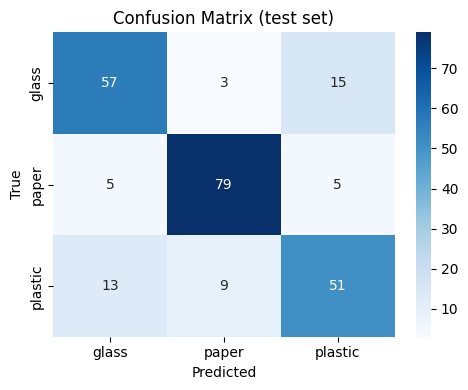

In [10]:
y_pred = best_pipe.predict(X_test)
target_names = list(le.classes_)

report = classification_report(y_test,y_pred,target_names=target_names,digits=4)
print(report)

# save report to a text file too
with open(os.path.join(MODELS_DIR,"classification_report.txt"),"w",encoding="utf-8") as f:
    f.write(report)

cm = confusion_matrix(y_test,y_pred)
fig,ax = plt.subplots(figsize=(5,4))
sns.heatmap(
    cm,annot=True,fmt="d",cmap="Blues",
    xticklabels=target_names,yticklabels=target_names,ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (test set)")
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR,"confusion_matrix.png"),dpi=150)
plt.show()

## 11. Inference latency

Proposal target (Section 4,Table 2): **<= 200 ms** per image (minimum),**<= 100 ms** (ideal).

We measure end-to-end latency on the test set: feature extraction + scaling + SVM predict,the same pipeline `app.py` runs on each upload.

In [ ]:
# Per-stage timing on the test set,in milliseconds.
# Total = load + resize/gray + feature extraction + scale/pca/SVM predict.
# scale_predict now runs the full fitted pipeline (StandardScaler -> PCA -> SVM),
# exactly what app.py executes per upload.
stage_keys = ["load","preproc","color_hist","color_moments",
              "lbp","glcm","hog","edge","scale_predict","total"]
stage_times = {k: [] for k in stage_keys}

for p in p_test:
    t_start = time.perf_counter()

    t0 = time.perf_counter()
    img = load_image(p)
    stage_times["load"].append((time.perf_counter()-t0)*1000)

    t0 = time.perf_counter()
    img_r = resize_img(img)
    gray = to_gray(img_r)
    stage_times["preproc"].append((time.perf_counter()-t0)*1000)

    t0 = time.perf_counter(); ch = color_hist(img_r);     stage_times["color_hist"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); cm = color_moments(img_r);  stage_times["color_moments"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); lb = lbp_hist(gray);        stage_times["lbp"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); gl = glcm_feat(gray);       stage_times["glcm"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); hg = hog_feat(gray);        stage_times["hog"].append((time.perf_counter()-t0)*1000)
    t0 = time.perf_counter(); ed = edge_feat(gray);       stage_times["edge"].append((time.perf_counter()-t0)*1000)

    feats = np.concatenate([ch,cm,lb,gl,hg,ed]).astype("float32").reshape(1,-1)

    t0 = time.perf_counter()
    _ = best_pipe.predict(feats)   # StandardScaler -> PCA -> SVM
    stage_times["scale_predict"].append((time.perf_counter()-t0)*1000)

    stage_times["total"].append((time.perf_counter()-t_start)*1000)

latencies = np.array(stage_times["total"])

print("="*56)
print("  INFERENCE SPEED (milliseconds,per image,test set)")
print("="*56)
print(f"{'stage':<16} {'mean':>8} {'median':>8} {'p95':>8} {'max':>8}")
print("-"*56)
for k in stage_keys:
    arr = np.array(stage_times[k])
    print(f"{k:<16} {arr.mean():>8.2f} {np.median(arr):>8.2f} "
          f"{np.percentile(arr,95):>8.2f} {arr.max():>8.2f}")
print("="*56)
print(f"  >> Total inference speed: {latencies.mean():.2f} ms/image  "
      f"(~{1000.0/latencies.mean():.1f} FPS)")
print("="*56)
print()
print("Proposal target: <=200 ms (min),<=100 ms (ideal)")
print("Pass min target:  ","YES" if latencies.mean() <= 200 else "NO")
print("Pass ideal target:","YES" if latencies.mean() <= 100 else "NO")

## 12. Learning curve (Accuracy)

Section 4 of the proposal asks for a Loss & Accuracy Curve to monitor over/underfitting. SVMs don't produce a per-epoch loss the way neural networks do,so the standard equivalent is a **learning curve**: train and CV accuracy plotted against training-set size.

F1-macro is already reported as a scalar in Section 10. We use 4 training-set sizes here (was 6) to keep this section fast--it still refits the model 4 x 5 = 20 times.

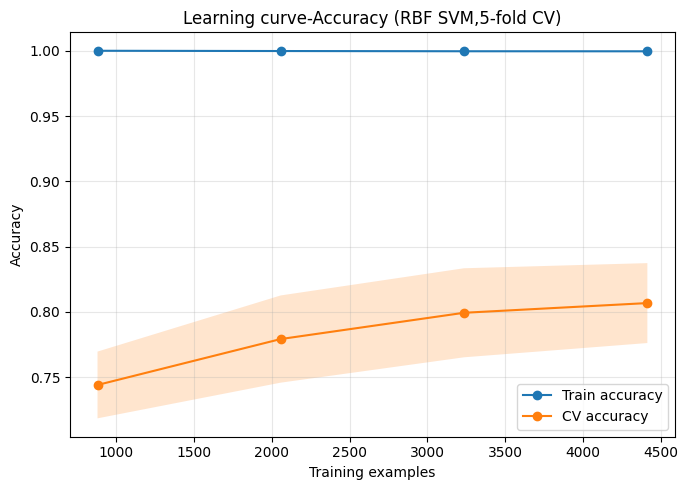

In [12]:
sizes,train_scores,val_scores = learning_curve(
    best_pipe,X_train,y_train,cv=5,
    train_sizes=np.linspace(0.2,1.0,4),
    scoring="accuracy",n_jobs=-1,random_state=RANDOM_STATE,shuffle=True,
)
tm,ts = train_scores.mean(axis=1),train_scores.std(axis=1)
vm,vs = val_scores.mean(axis=1),val_scores.std(axis=1)

fig,ax = plt.subplots(figsize=(7,5))
ax.plot(sizes,tm,"o-",label="Train accuracy")
ax.fill_between(sizes,tm-ts,tm + ts,alpha=0.2)
ax.plot(sizes,vm,"o-",label="CV accuracy")
ax.fill_between(sizes,vm-vs,vm + vs,alpha=0.2)
ax.set_xlabel("Training examples")
ax.set_ylabel("Accuracy")
ax.set_title("Learning curve-Accuracy (RBF SVM,5-fold CV)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR,"learning_curve.png"),dpi=150)
plt.show()

## 13. Save model artifacts

Refit the best hyperparameters one final time with `probability=True` so the
saved SVM supports `predict_proba` (used by `app.py` and `predict_demo.ipynb`).
This single fit is much faster than enabling probability through the whole grid
search.

The pipeline now has an extra PCA step, so we also dump `pca.joblib`. The
inference order is **scaler -> pca -> svm** (`app.py` applies the same chain).

In [ ]:
prob_pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("pca",PCA(
        n_components=grid.best_params_["pca__n_components"],
        whiten=True,
        svd_solver="randomized",
        random_state=RANDOM_STATE,
    )),
    ("svm",SVC(
        kernel="rbf",
        C=grid.best_params_["svm__C"],
        gamma=grid.best_params_["svm__gamma"],
        class_weight=grid.best_params_.get("svm__class_weight"),
        probability=True,
        cache_size=1000,
        decision_function_shape="ovo",
        random_state=RANDOM_STATE,
    )),
])
prob_pipe.fit(X_train,y_train)

fitted_scaler = prob_pipe.named_steps["scaler"]
fitted_pca = prob_pipe.named_steps["pca"]
fitted_svm = prob_pipe.named_steps["svm"]

joblib.dump(fitted_svm,os.path.join(MODELS_DIR,"svm_model.joblib"))
joblib.dump(fitted_scaler,os.path.join(MODELS_DIR,"scaler.joblib"))
joblib.dump(fitted_pca,os.path.join(MODELS_DIR,"pca.joblib"))
joblib.dump(le,os.path.join(MODELS_DIR,"label_encoder.joblib"))
joblib.dump({"X_test": X_test,"y_test": y_test},os.path.join(MODELS_DIR,"test_split.joblib"))

print("Saved model files to",MODELS_DIR)
print("Inference chain: scaler -> pca -> svm")